<a href="https://colab.research.google.com/github/Pedro4Albuquerque/09-DIS-Disney-Dire-o-de-Volume/blob/main/prova_09_pedro_souza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09: DIS (Disney) | Direção de Volume:
**Alvo (Y):** 1 (Crescente) ou 0 (Decrescente) em relação ao dia anterior.

**Desafio:** Prever se o fechamento atual é influenciado pelo volume da véspera.
## Aluno : Pedro Henrique Albuquerque Souza

# Pipeline 1 | Carregamento dos Dados via API [DIS - Disney]

In [28]:

from typing import List
import requests
import pandas as pd

API_KEY = "YF91FPXACQJ396DA"
SYMBOL = "DIS"

url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={SYMBOL}&outputsize=compact&apikey={API_KEY}'
r = requests.get(url)
data = r.json()

dados = data["Time Series (Daily)"]

base_dis = pd.DataFrame.from_dict(
    dados,
    orient="index"
)

base_dis

,1. open,2. high,3. low,4. close,5. volume
2026-05-06,106.5150,109.1400,105.3100,108.0600,23048302
2026-05-05,101.5300,101.7300,100.0600,100.4800,14314678
2026-05-04,102.7400,103.0500,101.2700,101.3100,8400068
2026-05-01,104.4000,104.8325,102.9700,103.0800,5956945
2026-04-30,100.9100,104.1200,100.4200,103.7500,9203503
...,...,...,...,...,...
2025-12-17,111.0600,112.1300,110.4550,110.6300,12142521
2025-12-16,111.2150,112.8499,110.8550,111.6200,15580195
2025-12-15,110.7000,111.5500,108.5500,110.4900,14317985
2025-12-12,111.7300,113.3400,111.1500,111.6000,13059066


## Blibliotecas de Python

In [29]:
!pip -q install plotly
!pip -q install yellowbrick

In [30]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Pipeline 2 | Organização e Limpeza

In [31]:
base_dis.index = pd.to_datetime(base_dis.index)

base_dis = base_dis.rename(columns={
    "1. open": "Open",
    "2. high": "High",
    "3. low": "Low",
    "4. close": "Close",
    "5. volume": "Volume"
})

base_dis = base_dis.astype(float)

base_dis = base_dis.sort_index()

base_dis

,Open,High,Low,Close,Volume
2025-12-11,109.200,111.5600,109.110,111.46,13281383.0
2025-12-12,111.730,113.3400,111.150,111.60,13059066.0
2025-12-15,110.700,111.5500,108.550,110.49,14317985.0
2025-12-16,111.215,112.8499,110.855,111.62,15580195.0
2025-12-17,111.060,112.1300,110.455,110.63,12142521.0
...,...,...,...,...,...
2026-04-30,100.910,104.1200,100.420,103.75,9203503.0
2026-05-01,104.400,104.8325,102.970,103.08,5956945.0
2026-05-04,102.740,103.0500,101.270,101.31,8400068.0
2026-05-05,101.530,101.7300,100.060,100.48,14314678.0


# Pipeline 3 | Análise Exploratória

## Mostra informações gerais da tabela.

In [32]:
base_dis.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100 entries, 2025-12-11 to 2026-05-06
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    100 non-null    float64
 1   High    100 non-null    float64
 2   Low     100 non-null    float64
 3   Close   100 non-null    float64
 4   Volume  100 non-null    float64
dtypes: float64(5)
memory usage: 4.7 KB


## Gera estatísticas automáticas das colunas numéricas.

In [33]:
base_dis.describe()

,Open,High,Low,Close,Volume
count,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,105.575400,106.794345,104.545875,105.662100,1.085760e+07
std,5.811029,5.889894,5.849219,5.944899,4.987756e+06
min,92.890000,94.190000,92.185000,92.420000,4.606746e+06
25%,101.240000,101.856650,100.195000,101.307500,8.100944e+06
50%,105.005000,106.744950,103.972500,105.245000,9.712002e+06
75%,111.251250,112.800000,110.512500,111.347500,1.206361e+07
max,114.770000,116.030000,114.100000,115.880000,3.777850e+07


## Verifica valores vazios (NaN) na tabela.

In [34]:
base_dis.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0


# Pipeline 4 | Visualização de Dados

## Fechamento das ações

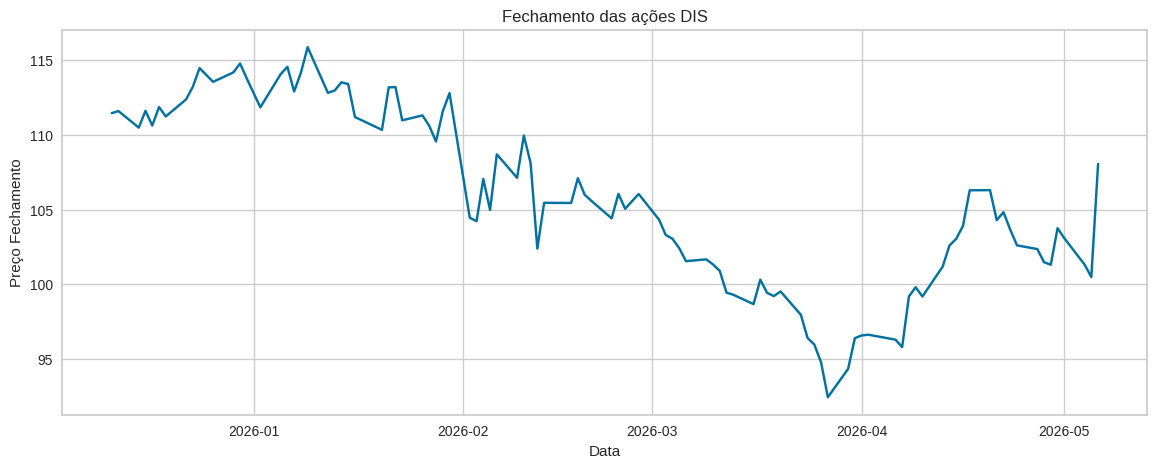

In [35]:
plt.figure(figsize=(14,5))

plt.plot(base_dis.index, base_dis["Close"])

plt.title("Fechamento das ações DIS")
plt.xlabel("Data")
plt.ylabel("Preço Fechamento")

plt.show()

## Volume negociado

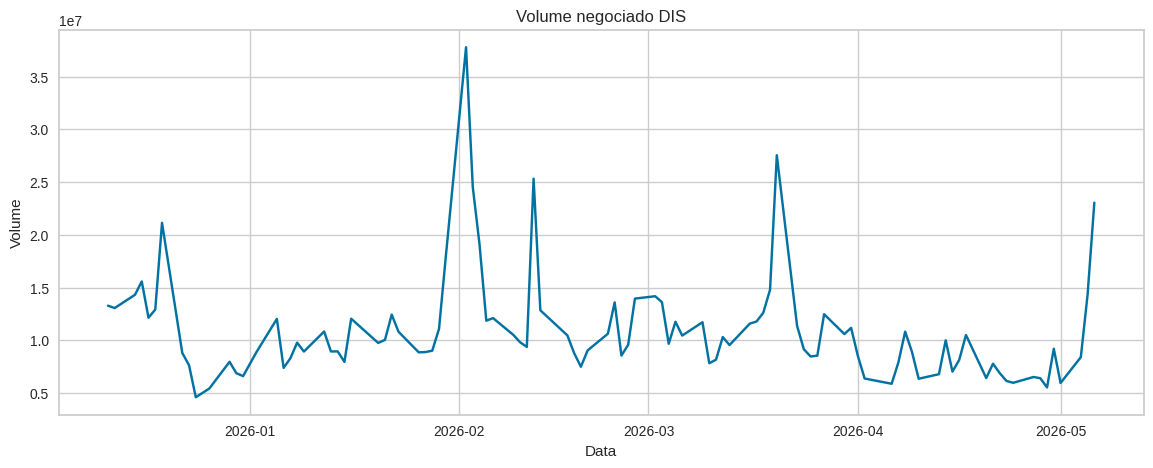

In [36]:
plt.figure(figsize=(14,5))

plt.plot(base_dis.index, base_dis["Volume"])

plt.title("Volume negociado DIS")
plt.xlabel("Data")
plt.ylabel("Volume")

plt.show()

## Correlação

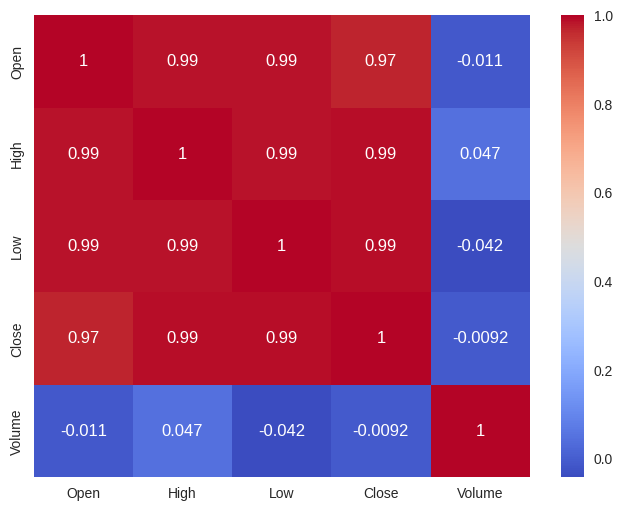

In [37]:
plt.figure(figsize=(8,6))

sns.heatmap(
    base_dis.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Pipeline 5 | Engenharia de Features

## Criação do alvo Y

In [38]:
base_dis["fechamento_anterior"] = base_dis["Close"].shift(1)

base_dis["direcao"] = np.where(
    base_dis["Close"] > base_dis["fechamento_anterior"],
    1,
    0
)

In [39]:
base_dis

,Open,High,Low,Close,Volume,fechamento_anterior,direcao
2025-12-11,109.200,111.5600,109.110,111.46,13281383.0,NaN,0
2025-12-12,111.730,113.3400,111.150,111.60,13059066.0,111.46,1
2025-12-15,110.700,111.5500,108.550,110.49,14317985.0,111.60,0
2025-12-16,111.215,112.8499,110.855,111.62,15580195.0,110.49,1
2025-12-17,111.060,112.1300,110.455,110.63,12142521.0,111.62,0
...,...,...,...,...,...,...,...
2026-04-30,100.910,104.1200,100.420,103.75,9203503.0,101.30,1
2026-05-01,104.400,104.8325,102.970,103.08,5956945.0,103.75,0
2026-05-04,102.740,103.0500,101.270,101.31,8400068.0,103.08,0
2026-05-05,101.530,101.7300,100.060,100.48,14314678.0,101.31,0


## Volume da véspera

In [40]:
base_dis["volume_anterior"] = base_dis["Volume"].shift(1)

## Removendo valores nulos

In [41]:
base_dis.dropna(inplace=True)

# Pipeline 6 | Separação X e Y

In [42]:
X_dis = base_dis[
    [
      "volume_anterior"
    ]
].values

Y_dis = base_dis["direcao"].values

# Pipeline 7 | Normalização

In [43]:
from sklearn.preprocessing import StandardScaler

scaler_dis = StandardScaler()

X_dis = scaler_dis.fit_transform(X_dis)

# Pipeline 8 | Treinamento

In [44]:
from sklearn.model_selection import train_test_split

X_treinamento, X_teste, Y_treinamento, Y_teste = train_test_split(
    X_dis,
    Y_dis,
    test_size=0.15,
    random_state=0,
    shuffle=False
)

X_treinamento.shape, X_teste.shape

((84, 1), (15, 1))

# Pipeline 9 | Treinamento GaussianNB

In [45]:
from sklearn.naive_bayes import GaussianNB

modelo_dis = GaussianNB()

modelo_dis.fit(
    X_treinamento,
    Y_treinamento
)

GaussianNB()

# Pipeline 10 | Previsões

In [46]:
previsoes = modelo_dis.predict(X_teste)

previsoes

array([0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0])

# Pipeline 11 | Avaliação

In [47]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

Acurácia

In [48]:
accuracy_score(
    Y_teste,
    previsoes
)

0.6666666666666666

Matriz de Confusão

In [49]:
confusion_matrix(
    Y_teste,
    previsoes
)

array([[7, 2],
       [3, 3]])

Relatório

In [50]:
print(
    classification_report(
        Y_teste,
        previsoes
    )
)

              precision    recall  f1-score   support

           0       0.70      0.78      0.74         9
           1       0.60      0.50      0.55         6

    accuracy                           0.67        15
   macro avg       0.65      0.64      0.64        15
weighted avg       0.66      0.67      0.66        15



# Pipeline 12 | Yellowbrick

In [51]:
from yellowbrick.classifier import ConfusionMatrix

0.6666666666666666

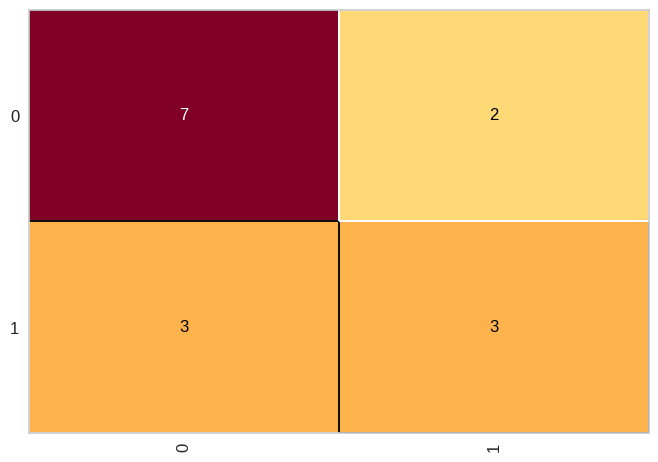

In [52]:
cm_dis = ConfusionMatrix(modelo_dis)

cm_dis.fit(
    X_treinamento,
    Y_treinamento
)

cm_dis.score(
    X_teste,
    Y_teste
)

Distribuição do alvo

<Axes: xlabel='direcao', ylabel='count'>

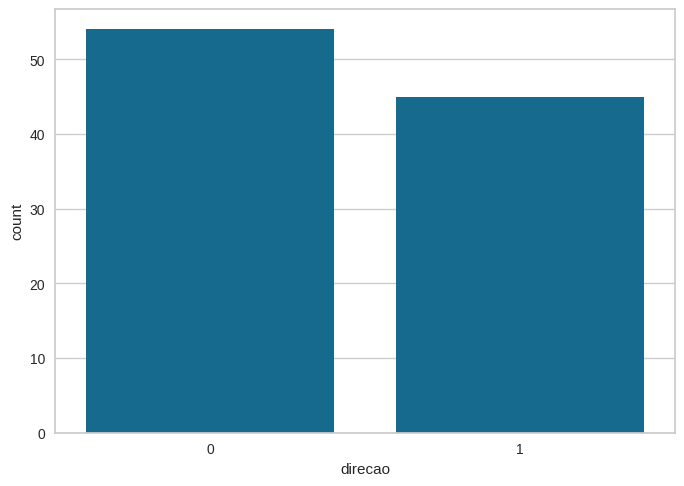

In [53]:
sns.countplot(x=base_dis["direcao"])

Gráfico interativo

In [54]:
grafico = px.line(
    base_dis,
    x=base_dis.index,
    y="Close",
    title="Fechamento DIS"
)

grafico.show()